In [1]:
%load_ext autoreload
%autoreload 2

# Visualise sequence mutations for Thesis

Dataset overview:

1. Dataset `2024_11_27_145142` was resimulated with different starting copy numbers in the following: 
Datasets:
- Original: `2024_11_27_145142`
- Starting copies = 100, dt0 = 0.0001: `2026_01_12__18_50_13`
- Starting copies = 200, dt0 = 0.0001: `2026_01_14__22_38_47`
- Starting copies = 100, dt0 = 0.01: `2026_01_15__15_43_12`

2. Dataset `2024_11_21_160955` was resimulated as dataset `2025_02_11__13_56_51`. 

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import os

from common import set_theme, add_sample_names
from synbio_morpher.utils.results.analytics.timeseries import calculate_adaptation

PALETTE = 'viridis'

set_theme()

top_write_dir = os.path.join('figures', '04_mutations')

In [3]:
'data/raw/summarise_simulation/2024_11_21_160955/tabulated_mutation_info.csv'
'data/simulate_circuits/2026_01_12__18_50_13/config.json'
'data/simulate_circuits/2026_01_12__18_50_13/analytics.json'

'data/simulate_circuits/2026_01_12__18_50_13/analytics.json'

In [4]:
fn_og = '../data/raw/summarise_simulation/2024_11_27_145142/tabulated_mutation_info.csv'
fn_resim = '../notebooks/data/simulate_circuits/2026_01_12__18_50_13/analytics.json'
data = pd.read_csv(fn_og)
df_resim = pd.read_json(fn_resim).drop(columns='RMSE')
df_resim = df_resim.explode(df_resim.columns.to_list()).reset_index(drop=True)
cols_resim = list(df_resim.columns)

In [5]:
names_species_input = data['sample_name'].unique()
n_species_input = len(names_species_input)
n_species_total = int(len(df_resim) / len(data) * n_species_input)

df_resim = add_sample_names(df_resim, names_species_input, n_species_input, n_species_total)
data[cols_resim] = df_resim.query('sample_name in ["RNA_0", "RNA_1", "RNA_2"]')[cols_resim].values.astype(np.float32)
del df_resim

data.rename(columns={'mutation_num': 'N mutations'}, inplace=True)
data['Log sensitivity'] = np.log10(data['sensitivity'])
data['Log precision'] = np.log10(data['precision'])
data['adaptation'] = calculate_adaptation(np.array(data['sensitivity']), np.array(data['precision']), alpha=2)

In [6]:
from synbio_morpher.utils.results.analytics.naming import get_true_interaction_cols
x_cols = get_true_interaction_cols(data, 'energies', remove_symmetrical=True, num_species=3)
x_cols_self = [x_cols[0], x_cols[3], x_cols[5]]
x_cols_inter = [x_cols[1], x_cols[2], x_cols[4]]
x_cols_rna = [f'$RNA_{i}$-$RNA_{j}$' for i in range(1, 4) for j in range(1, 4) if i <= j]
titles = x_cols_rna

In [7]:
for k in ['Log sensitivity', 'Log precision', 'adaptation']:
    # data[f'{k} diffs'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x - x.iloc[0]).reset_index()[k]
    data[f'{k} diffs'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x - x.iloc[0]).reset_index().sort_values('level_2').reset_index()[k]
    data[f'{k} ratio'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x/x.iloc[0]).reset_index().sort_values('level_2').reset_index()[k]

In [8]:
filt_adapt = (data['Log sensitivity'] > -1) & (data['Log precision'] > 0.5)
filt_adapt_strict = (data['Log sensitivity'] >= 0.) & (data['Log precision'] >= 1.0)
filt_m = data['N mutations'] > 0
filt_samp = data['sample_name'] == 'RNA_2'

data['is_null'] = data[x_cols].sum(axis=1) == 0
circuits_null_og = data[(
    data['mutation_name'] == 'ref_circuit') & data['is_null']]['circuit_name'].unique()
# data['was_only_mut_null'] = (~data['circuit_name'].isin(circuits_null_og)
#                                      & data['is_null'])
data['was_only_mut_null'] = (data['mutation_name'] != 'ref_circuit') & data['is_null']

# Loss of adaptable circuits

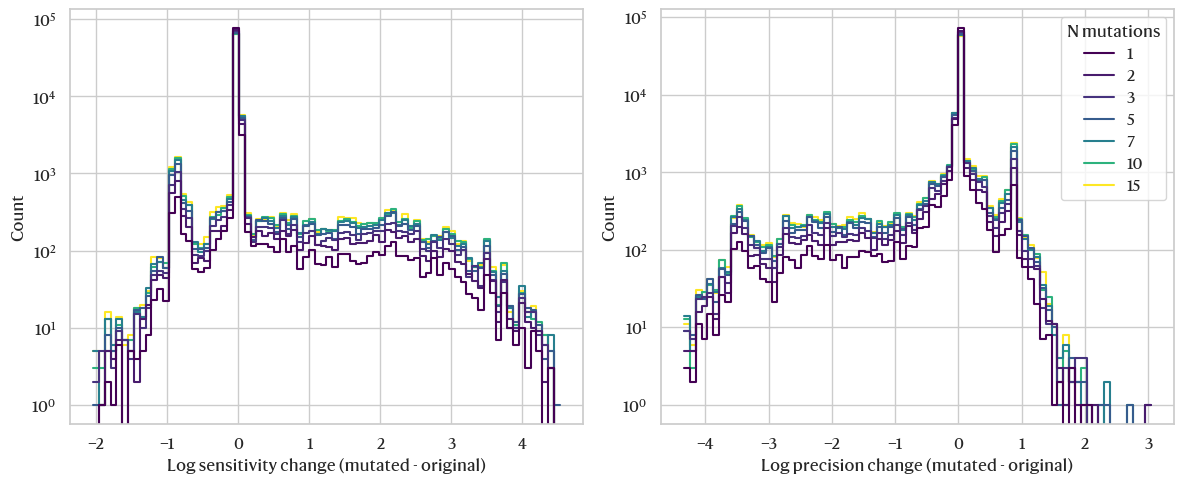

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data[filt_adapt & filt_m & filt_samp], x=f'Log sensitivity diffs', hue='N mutations',
            palette=PALETTE, bins=80, fill=False, element='step', ax=axs[0], legend=False)
axs[0].set_yscale('log')
axs[0].set_xlabel('Log sensitivity change (mutated - original)')
sns.histplot(data[filt_adapt & filt_m & filt_samp], x=f'Log precision diffs', hue='N mutations',
            palette=PALETTE, bins=80, fill=False, element='step', ax=axs[1], legend=True)
axs[1].set_yscale('log')
axs[1].set_xlabel('Log precision change (mutated - original)')

plt.tight_layout()
plt.savefig(os.path.join(top_write_dir, 'prec_sens_diffs.png'), 
            bbox_inches='tight', dpi=300)

What are the circuits at the peaks? Is that an attractor topology?

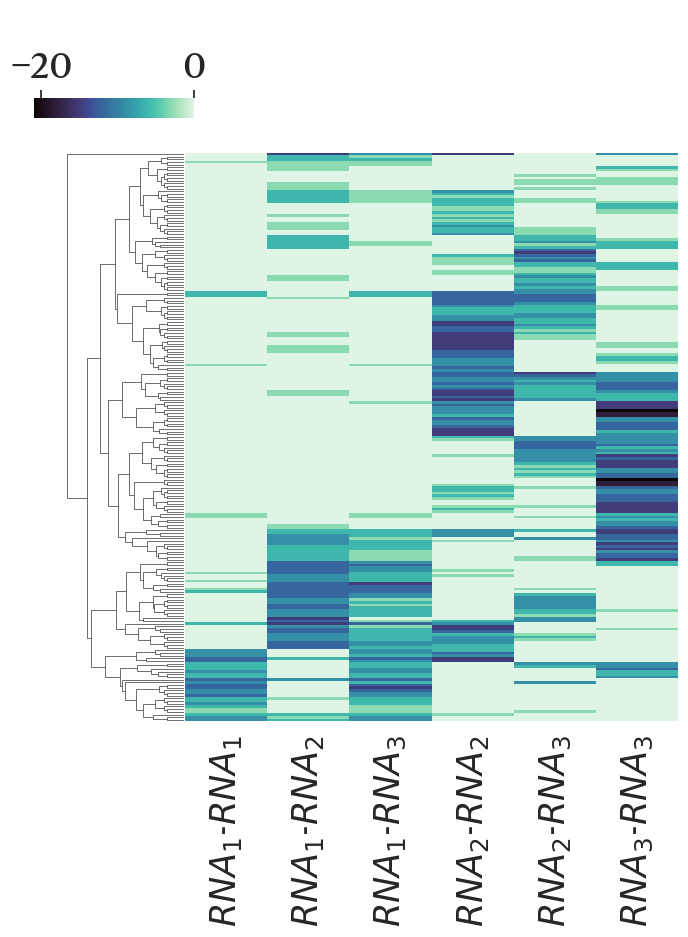

In [65]:
# cols_timeseries = ['steady_states', 'initial_steady_states']
# cols_timeseries_quantised = ['Steady states', 'Initial steady states']
# data[cols_timeseries_quantised] = (data[cols_timeseries] / 20).round(0) * 20
# from matplotlib.colors import LinearSegmentedColormap
# cmap = LinearSegmentedColormap.from_list(
#     "_",
#     [(0.0, "blue"), (0.165, "white"), (0.5, "red"), (1.0, "yellow")]
# )

x_cols_quantised = [f'{i}_quant' for i in x_cols]
quantisation = 3
data[x_cols_quantised] = (data[x_cols] / quantisation).round(0) * quantisation

cols_to_plot = x_cols_quantised # + cols_timeseries_quantised
filt_here = filt_adapt & filt_m & filt_samp & data['Log sensitivity diffs'].between(-1, -0.8)
cmap = 'mako'
g = sns.clustermap(data[filt_here][cols_to_plot].value_counts().reset_index()[cols_to_plot].rename(
        columns={x: t for x, t in zip(x_cols_quantised, titles)}
    ), 
    cmap=cmap, col_cluster=False, figsize=(7, 10), 
    yticklabels=False, cbar_kws={'location': 'top'})
x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([x0, 0.85, g.ax_row_dendrogram.get_position().width * 1.3, 0.02])

plt.savefig(os.path.join(top_write_dir, 'mut_sensitivity_clustermap.png'),
            dpi=300, bbox_inches='tight')

In [11]:
cols_timeseries = ['steady_states', 'initial_steady_states']
data[filt_here][['Log sensitivity', 'Log precision'] + cols_timeseries].describe()

,Log sensitivity,Log precision,steady_states,initial_steady_states
count,15131.000000,15131.000000,15131.000000,15131.000000
mean,-0.603106,0.634658,94.982956,95.042267
std,0.036067,0.098169,14.735599,14.712143
min,-0.993516,0.510182,1.207712,1.208116
25%,-0.602806,0.602806,99.832886,99.866165
50%,-0.602806,0.602806,99.832886,99.866165
75%,-0.602806,0.602806,99.832886,99.866165
max,0.322396,2.318989,99.858551,99.891853


Text(32.25, 0.5, 'Log sensitivity after mutation')

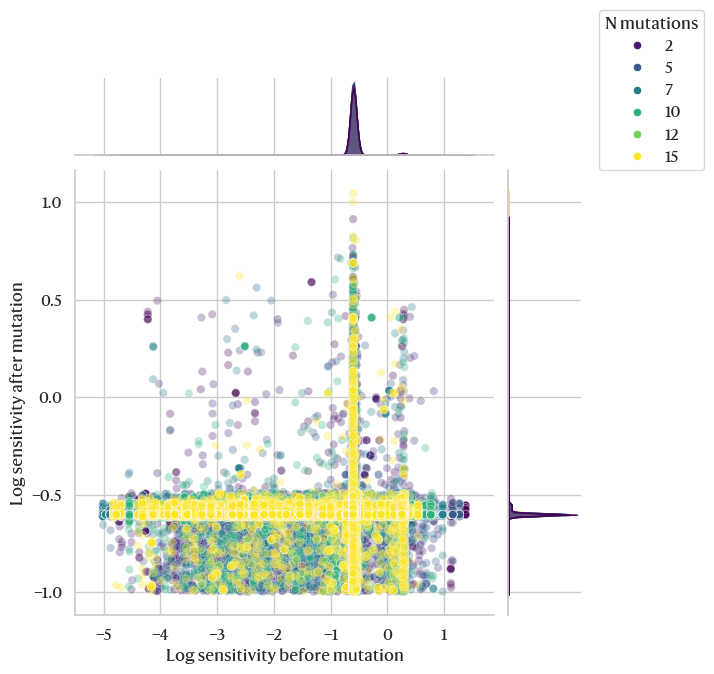

In [18]:
g = sns.jointplot(data[filt_adapt & filt_m].sort_values('N mutations'),
                    x=data[filt_adapt & filt_m]['Log sensitivity'].values - 
                    data[filt_adapt & filt_m]['Log sensitivity diffs'].values,
                    y='Log sensitivity',  
                hue='N mutations', palette=PALETTE, alpha=0.3)
for line in g.ax_joint.legend().get_lines():
    line.set_alpha(1.0)
sns.move_legend(g.ax_joint, [1.0, 1.0], bbox_to_anchor=(1.25, 1), title='N mutations')
plt.xlabel('Log sensitivity before mutation')
plt.ylabel('Log sensitivity after mutation')

# plt.tight_layout()
# plt.savefig(os.path.join(top_write_dir, 'joint_sens_change.png'), 
#             bbox_inches='tight', dpi=300)

# Visualise binding energy

In [9]:
for k in x_cols:
    data[f'{k} diffs'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x - x.iloc[0]).reset_index().sort_values('level_2').reset_index()[k]
x_cols_diffs = [f'{k} diffs' for k in x_cols]
x_cols_self_diffs = [f'{k} diffs' for k in x_cols_self]
x_cols_inter_diffs = [f'{k} diffs' for k in x_cols_inter]


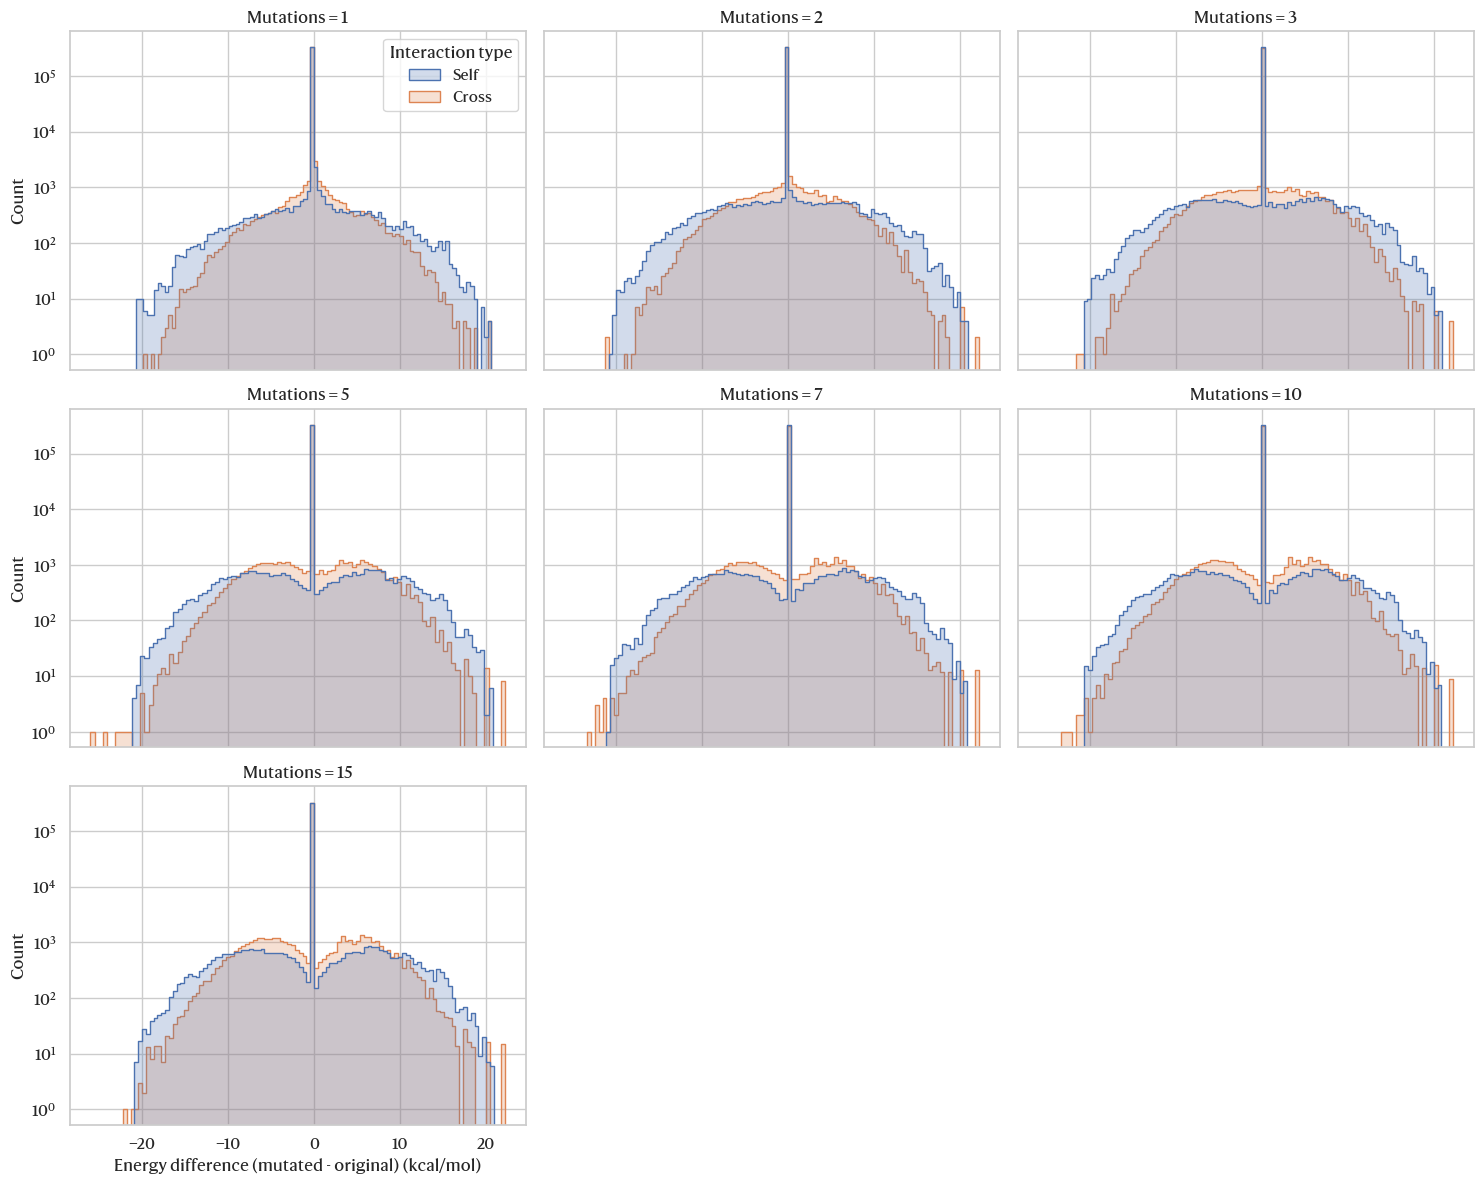

In [ ]:
all_mutations = sorted(data['N mutations'].unique())[1:]
ncols = int(np.ceil(np.sqrt(len(all_mutations))))
nrows = int(np.ceil(np.sqrt(len(all_mutations))))
fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharex=True, sharey=True)
for i, m in enumerate(all_mutations):
    dfm = data[filt_samp & (data['N mutations'] == m)].melt(
        value_vars=x_cols_diffs, var_name='interaction', value_name='energy_diff')
    dfm['Interaction type'] = dfm['interaction'].apply(lambda x: 'Self' if x in x_cols_self_diffs else 'Cross')
    sns.histplot(dfm, hue='Interaction type', legend=i == 0,
                x='energy_diff', bins=100, element='step', ax=axs.flat[i])
    axs.flat[i].set_yscale('log')
    axs.flat[i].set_title(f'Mutations = {m}')
    axs.flat[i].set_xlabel('Energy difference (mutated - original) (kcal/mol)')

for ii in range(i+1, ncols*nrows):
    axs.flat[ii].set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(top_write_dir, 'hist_binding_energy_selfcross.png'), bbox_inches='tight', dpi=300)

# Binding energies: functional -> null

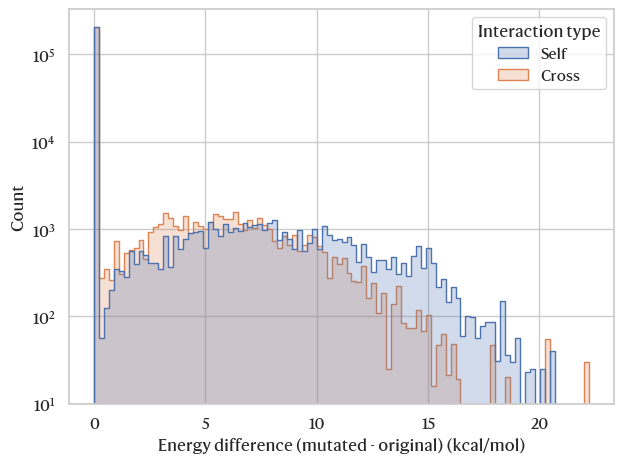

In [ ]:
dfm = data[filt_samp & data['was_only_mut_null']].melt(value_vars=x_cols_diffs, 
            var_name='interaction', value_name='energy_diff')
dfm['Interaction type'] = dfm['interaction'].apply(lambda x: 'Self' if x in x_cols_self_diffs else 'Cross')
sns.histplot(dfm, hue='Interaction type',
             x='energy_diff', bins=100, element='step', label='Self-interactions')
plt.yscale('log')
plt.xlabel('Energy difference (mutated - original) (kcal/mol)')

plt.tight_layout()
plt.savefig(os.path.join(top_write_dir, 'hist_binding_energy_selfcross_mutnull.png'), bbox_inches='tight', dpi=300)

# Motifs

In [11]:
data[filt_samp & filt_adapt_strict][x_cols + ['adaptation']]

,energies_0-0,energies_0-1,energies_0-2,energies_1-1,energies_1-2,energies_2-2,adaptation
334763,-2.60,0.00,-4.38,0.00,0.00,-14.96,863.197144
335009,-4.54,0.00,-6.35,0.00,0.00,-14.50,862.296265
386912,-5.04,0.00,-6.61,-10.36,0.00,-19.48,867.771606
658568,0.00,-3.58,-2.89,-8.92,-12.75,0.00,867.369812
727934,0.00,-8.63,0.00,-14.14,-13.25,-18.86,875.723633
734009,0.00,-6.23,-7.03,0.00,0.00,-17.28,873.712769
784871,-3.96,0.00,-5.47,0.00,0.00,-18.76,863.763794
964976,0.00,-6.79,-6.10,0.00,0.00,-14.92,862.790527
1256492,-6.00,0.00,-8.76,0.00,-8.13,-17.32,867.367188
1256501,0.00,-9.11,-8.63,0.00,-8.13,-17.32,866.332886


Radar plots

In [13]:
def plot_radar_chart(df, i, ax, cols, labels, color='tab:blue', linewidth=2, alpha=0.05):
    # Step 1: Prepare data
    categories = labels
    values = (df[cols].iloc[i].round(1)).tolist()
    values += values[:1]  # repeat first value to close the circle

    # Step 2: Calculate angles for each axis
    num_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    # Step 3: Create radar chart
    ax.plot(angles, values, color=color, linewidth=linewidth, alpha=alpha)
    # ax.fill(angles, values, color='tab:blue', alpha=0.25)

    # Step 4: Set labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_yticklabels([])  # hide radial ticks for cleaner look

    # Optional: Set range for radial axis
    # ax.set_ylim(0, 5)

Prepare clusters for plotting

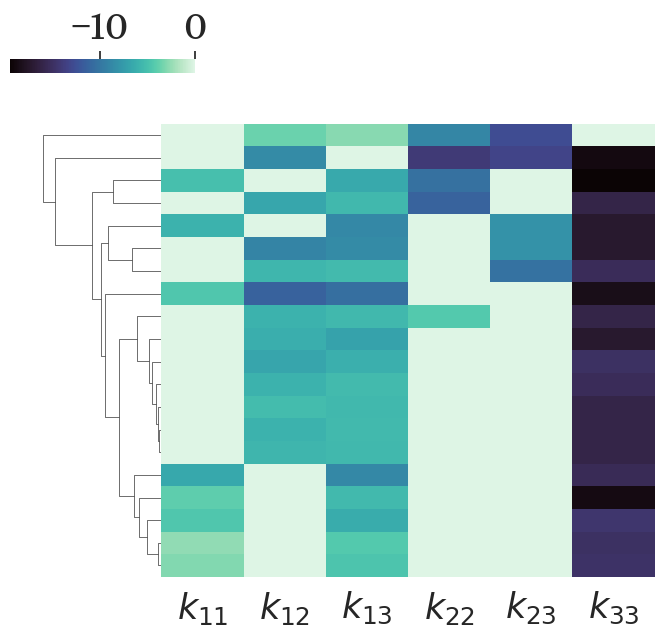

In [80]:
from scipy.cluster.hierarchy import fcluster
import itertools


df_plot = data[filt_samp & filt_adapt_strict].reset_index(drop=True)
n_species = data['sample_name'].nunique()
cols_e = [r'$k_{' + str(i) + str(j) + '}$' for i, j in sorted(set(
    [tuple(sorted(i)) for i in itertools.product(np.arange(n_species) + 1, np.arange(n_species) + 1)]))]
df_plot = df_plot.rename(columns={x: t for x, t in zip(x_cols, cols_e)})

g = sns.clustermap(df_plot[cols_e], col_cluster=False,
                   figsize=(7, 7), yticklabels=False, cmap='mako',
                   cbar_kws={'location': 'top'})
x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([x0, 0.85, g.ax_row_dendrogram.get_position().width * 1.5, 0.02])
plt.savefig(os.path.join(top_write_dir, 'motifs_adaptable.png'),
            dpi=300, bbox_inches='tight')

n_clusters = 5
row_linkage = g.dendrogram_row.linkage
clusters = fcluster(row_linkage, t=n_clusters, criterion='maxclust')


lut = dict(zip(sorted(pd.Series(clusters).unique()),
                sns.color_palette('pastel', n_clusters).as_hex()))
row_colors = pd.Series(clusters).map(lut).to_numpy()

df_plot['Cluster'] = clusters
clusters = np.unique(clusters)

hues = ['Log sensitivity', 'Log precision']
for k in hues:
    np.nanmin(df_plot[df_plot[k] < np.inf][k])
    df_plot[k + ' scaled'] = np.interp(
        df_plot[k].values, (np.nanmin(df_plot[df_plot[k] < np.inf][k]), 
                            np.nanmax(df_plot[df_plot[k] < np.inf][k])), (0, 1))
hues = hues + [k + ' scaled' for k in hues]



Visualise radar graphs

In [123]:
import matplotlib.colors as mcolors
sns.set_context("notebook", font_scale=2.3)


def outer_plot_radar(df_plot, data, hues, cmap, clusters, key_cluster='Cluster', 
savefig=True, savename='', n_blanks=2):
    
    max_line = 5
    for ih, hue in enumerate(hues):
        if 'scaled' in hue:
            # if 'Prompt' not in hue else all_sampled_cond[..., config_dataset.objective_col.index(k_rugg)].min()
            vmin = df_plot[hue].min()
            vmax = df_plot[hue].max()
        else:
            vmin = np.nanmin(data[filt_samp & (data[hue] < np.inf)][hue])
            vmax = np.nanmax(data[filt_samp & (data[hue] < np.inf)][hue])

        val_norm = (df_plot.sort_index()[hue].values - vmin) / (vmax - vmin)
        colors_all = np.array(
            list(map(lambda val: mcolors.to_hex(cmap(val)), val_norm)))

        for i_split, split in enumerate([(-np.inf, np.inf)]):

            df_curr = df_plot.reset_index(drop=True)[df_plot.reset_index(drop=True)
                                    [hue].between(*split, inclusive='both')]

            for orientation in ['horizontal']: #, 'vertical']:
                if orientation == 'horizontal':
                    dim_dom = 1
                    ncol = max_line + n_blanks   # Leaving 2 blanks for colorbar
                    nrow = 1 + len(clusters) // max_line
                else:
                    dim_dom = 0
                    nrow = max_line + n_blanks
                    ncol = 1 + len(clusters) // max_line

                fig, axs = plt.subplots(nrow, ncol, figsize=(
                    5*ncol, 5*nrow), subplot_kw=dict(polar=True))
                plt.subplots_adjust(wspace=0.1, hspace=-0.1)
                for ic, cluster in enumerate(clusters):

                    ax = axs.flat[ic + ic // max_line * n_blanks]

                    d = df_curr[df_curr[key_cluster] == cluster]
                    if len(d) == 0:
                        ax.set_axis_off()
                    colors = np.array(colors_all)[d.index.to_numpy()]

                    alpha = 0.05 if len(d) > 100 else (0.4 if len(d) > 20 else 0.9)
                    for i in d.reset_index().sort_values(hue, ascending=False).index:
                        plot_radar_chart(
                            d, i, ax, cols_e, labels=cols_e, color=colors[i], linewidth=5, alpha=alpha)

                norm = plt.Normalize(vmin=vmin, vmax=vmax)
                sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
                sm.set_array([])
                cbar = plt.colorbar(sm, ax=axs.flat[-1], orientation=orientation,
                                    pad=0.1, shrink=0.8 if orientation == 'horizontal' else 0.6)
                cbar.set_label(hue, rotation=0, labelpad=25)

                def turnoff(axs_all): 
                    for a in axs_all:
                        a.set_axis_off()

                if axs.ndim == 1:
                    turnoff(axs[-n_blanks:])
                elif axs.ndim > 1:
                    axt = axs.T if dim_dom == 0 else axs
                    for idim in range(axs.shape[int(not(dim_dom))]):
                        turnoff(axs[idim, -n_blanks:])
                    turnoff(axt.flat[(len(clusters) + (len(clusters) // max_line * n_blanks)):])

                plt.tight_layout()
                if savefig:
                    hue_short = hue.replace('Log ', '').replace('sensitivity', 'sens').replace(
                        'precision', 'prec').replace(' scaled', 'scaled')
                    suffix = f'{orientation[:3]}{i_split}_{ih}{hue_short}'
                    plt.savefig(os.path.join(top_write_dir, f'radar_clusters_{savename}_{suffix}.png'), dpi=300)

                if orientation == 'vertical':
                    plt.close()

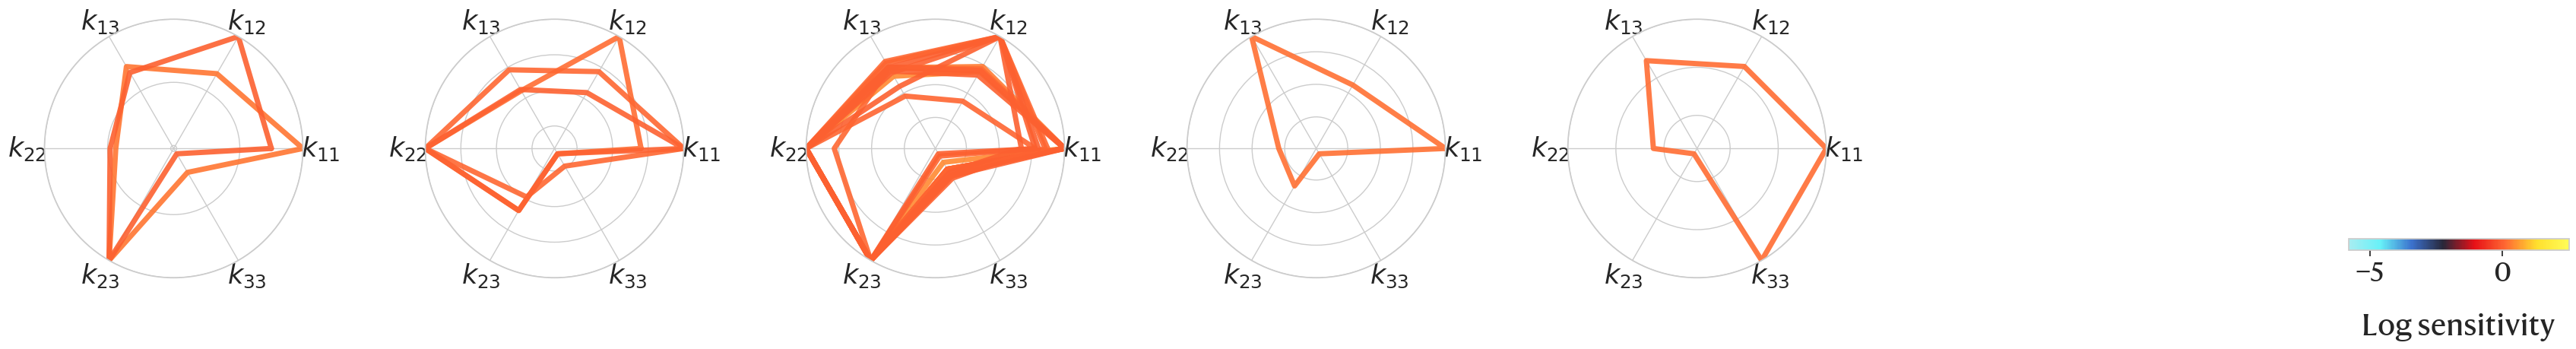

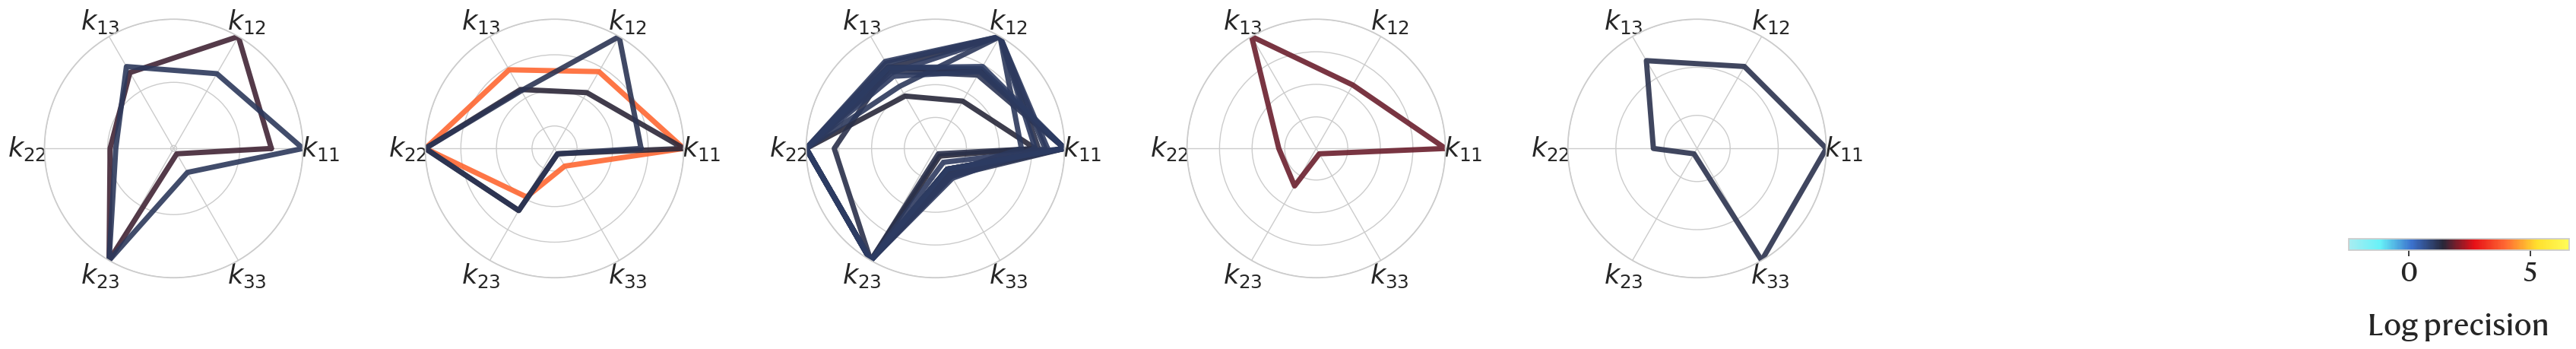

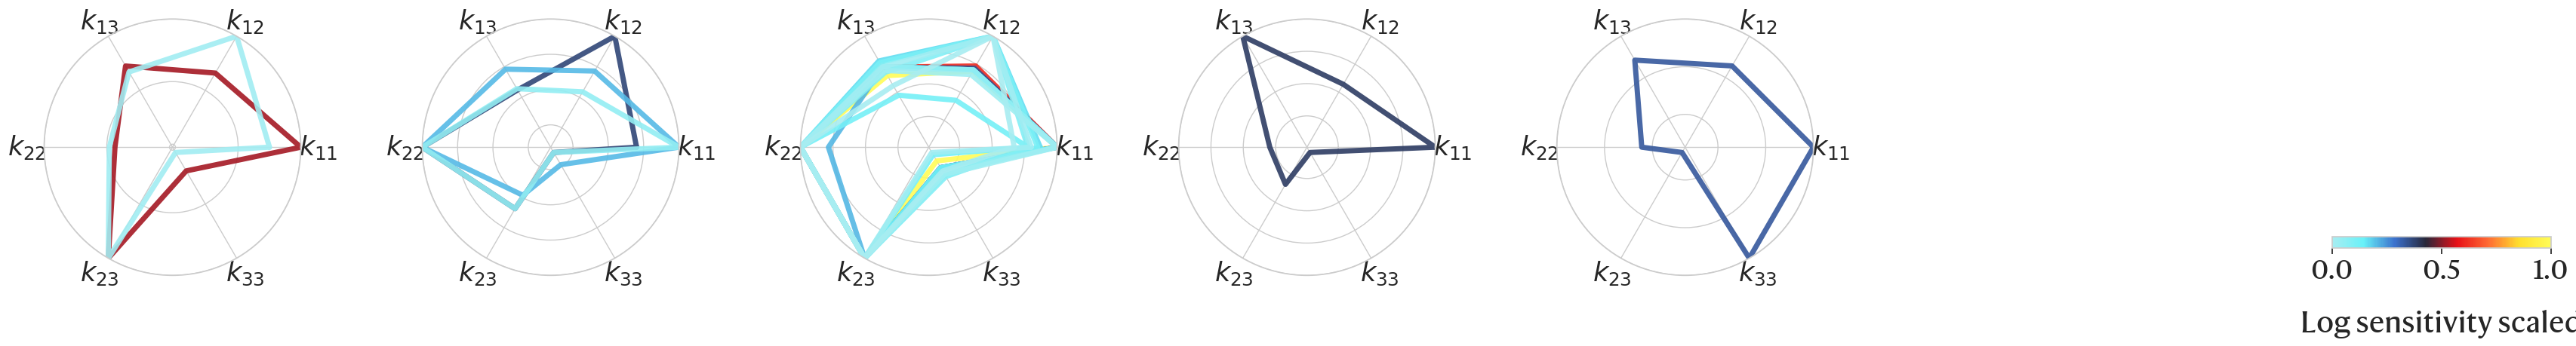

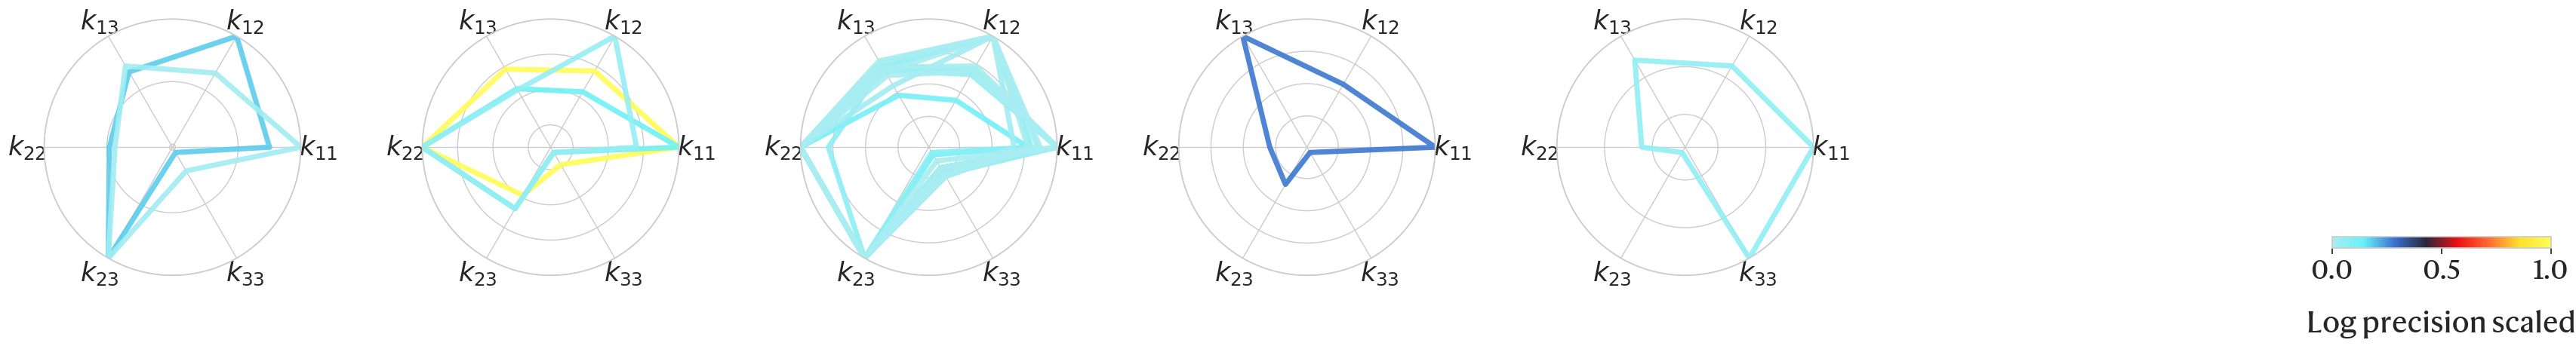

In [ ]:
palette = 'icefire'  # 'magma_r'    "#dcff19",
custom_palette3 = sns.blend_palette(["#a8edf1", "#68f1f8", '#3b71cd', '#282739',
                                    "#e71017", "#ff6a33", "#ffe02e", "#fffc58"], as_cmap=True)
# custom_palette3 = sns.color_palette('viridis', as_cmap=True)

outer_plot_radar(df_plot, data, hues, custom_palette3, clusters, key_cluster='Cluster', 
                 savefig=False, savename='adaptable')

In [99]:
circuits_adaptable = data[filt_samp & filt_adapt_strict]['circuit_name'].unique()

df_plot2 = data[filt_samp & data['circuit_name'].isin(circuits_adaptable)].reset_index(drop=True)
for k in hues:
    np.nanmin(df_plot2[df_plot2[k] < np.inf][k])
    df_plot2[k + ' scaled'] = np.interp(
        df_plot2[k].values, (np.nanmin(df_plot2[df_plot2[k] < np.inf][k]), 
                            np.nanmax(df_plot2[df_plot2[k] < np.inf][k])), (0, 1))
df_plot2 = df_plot2.rename(columns={k: v for k, v in zip(x_cols, cols_e)})

In [ ]:
outer_plot_radar(df_plot2,
                 data, hues, custom_palette3, circuits_adaptable, 
                 key_cluster='circuit_name', savefig=True, savename='adaptmuts',
                 n_blanks=1)
